In [1]:
import os
import pandas as pd
import requests
import json
from datetime import datetime

# Create data directory if it doesn't exist
DATA_DIR = "data"

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)
    print(" Data folder created successfully")
else:
    print(" Data folder already exists")

print(" Libraries are ready!")

 Data folder created successfully
 Libraries are ready!


In [2]:
import requests
from bs4 import BeautifulSoup
import json
import os


# CONFIG

STEEL_URL = "https://www.as3armasr.com/construction/iron-prices"
CEMENT_URL = "https://www.as3armasr.com/construction/cement-prices"

STEEL_RANGE = (35000, 60000)
CEMENT_RANGE = (1500, 5000)

DATA_DIR = "data"
OUTPUT_FILE = os.path.join(DATA_DIR, "integrated_market_data.json")


# EXCHANGE RATE

def get_exchange_rate():
    url = "https://open.er-api.com/v6/latest/USD"
    try:
        response = requests.get(url, timeout=10)
        data = response.json()
        return data['rates']['EGP']
    except Exception as e:
        print(f" Exchange rate error: {e}")
        return 53.0


# SCRAPER

def scrape_market_price(url, price_range, default_value):
    headers = {'User-Agent': 'Mozilla/5.0'}

    try:
        response = requests.get(url, headers=headers, timeout=15)
        soup = BeautifulSoup(response.content, 'lxml')

        for tag in soup.find_all('td'):
            text = tag.text.strip().replace(',', '')

            if text.isdigit():
                value = int(text)
                if price_range[0] < value < price_range[1]:
                    return value

        return default_value

    except Exception as e:
        print(f" Scraping failed for {url}: {e}")
        return default_value


# PIPELINE

def run_pipeline():
    print("--- Running Construction BI Pipeline ---")

    # ensure folder exists
    if not os.path.exists(DATA_DIR):
        os.makedirs(DATA_DIR)

    usd_to_egp = get_exchange_rate()

    # steel
    print(" Scraping steel prices...")
    iron_base_price = scrape_market_price(
        STEEL_URL,
        STEEL_RANGE,
        41500
    )

    # cement
    print(" Scraping cement prices...")
    cement_base_price = scrape_market_price(
        CEMENT_URL,
        CEMENT_RANGE,
        2100
    )

    # structured output
    market_data = [
        {"item": "Ezz Steel", "type": "Steel", "price": iron_base_price + 1000},
        {"item": "Suez Steel", "type": "Steel", "price": iron_base_price},
        {"item": "Reinforced Cement", "type": "Cement", "price": cement_base_price + 100},
        {"item": "Suwedi Cement", "type": "Cement", "price": cement_base_price + 250}
    ]

    final_output = {
        "usd_rate": usd_to_egp,
        "results": market_data,
        "timestamp": "Live Web Data"
    }

    # save file
    with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
        json.dump(final_output, f, indent=4, ensure_ascii=False)

    print(" Pipeline completed successfully")
    print(f" Steel base: {iron_base_price} |  Cement base: {cement_base_price}")


if __name__ == "__main__":
    run_pipeline()

--- Running Construction BI Pipeline ---
 Scraping steel prices...
 Scraping cement prices...
 Pipeline completed successfully
 Steel base: 41500 |  Cement base: 2100


In [3]:
import yfinance as yf

# 1. Download data (daily to ensure proper monthly averaging)
data = yf.download("USDEGP=X", start="2016-04-01", end="2026-05-01")

# 2. Convert to monthly average in one step
df_usd_monthly = data['Close'].resample('MS').mean().reset_index()
df_usd_monthly.columns = ['Date', 'USD_Average']

# 3. Display first 10 months (averages)
print("Monthly average USD exchange rate:")
print(df_usd_monthly.head(10))

/tmp/ipykernel_5117/1863322098.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("USDEGP=X", start="2016-04-01", end="2026-05-01")
[*********************100%***********************]  1 of 1 completed

Monthly average USD exchange rate:
        Date  USD_Average
0 2016-04-01     8.856905
1 2016-05-01     8.857295
2 2016-06-01     8.841650
3 2016-07-01     8.851590
4 2016-08-01     8.865178
5 2016-09-01     8.868155
6 2016-10-01     8.868728
7 2016-11-01    15.663632
8 2016-12-01    18.454614
9 2017-01-01    18.596886


In [4]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

def get_historical_usd(years=10):
    print(f"Fetching historical USD data for {years} years...")

    # Define date range (last X years to today)
    end_date = datetime.now().strftime('%Y-%m-%d')
    start_date = (datetime.now() - timedelta(days=years * 365)).strftime('%Y-%m-%d')

    try:
        # Download USD/EGP pair data
        data = yf.download("USDEGP=X", start=start_date, end=end_date)

        if data.empty:
            print("No data found. Check internet connection.")
            return None

        # Clean data
        df_usd = data[['Close']].reset_index()
        df_usd.columns = ['Date', 'USD_Price']
        df_usd['Date'] = pd.to_datetime(df_usd['Date']).dt.strftime('%Y-%m-%d')

        print(f"Successfully fetched {len(df_usd)} days of USD data.")
        return df_usd

    except Exception as e:
        print(f"Error while fetching data: {e}")
        return None

# Run function
historical_usd_df = get_historical_usd(10)

if historical_usd_df is not None:
    print(historical_usd_df.head())

Fetching historical USD data for 10 years...


/tmp/ipykernel_5117/1064842180.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("USDEGP=X", start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Successfully fetched 2598 days of USD data.
         Date  USD_Price
0  2016-05-09     8.8709
1  2016-05-10     8.8576
2  2016-05-11     8.8558
3  2016-05-12     8.8574
4  2016-05-13     8.8567


In [7]:
import pandas as pd
import os

cement_path = "cement_2016_2026.xlsx"
steel_path = "steel_2026.csv"

# Check files exist
if not os.path.exists(cement_path):
    raise FileNotFoundError(f"Missing file: {cement_path}")

if not os.path.exists(steel_path):
    raise FileNotFoundError(f"Missing file: {steel_path}")

# Load data
df_cement = pd.read_excel(cement_path)
df_steel = pd.read_csv(steel_path)

# Basic validation
print("Cement shape:", df_cement.shape)
print("Steel shape:", df_steel.shape)

print("Data loaded successfully")

Cement shape: (119, 3)
Steel shape: (119, 4)
Data loaded successfully


In [8]:
print("Cement Data:")
display(df_cement.head())

print("\nCement file information:")
df_cement.info()

# Additional safety checks
print("\nMissing values:")
print(df_cement.isnull().sum())

print("\nDuplicate rows:", df_cement.duplicated().sum())

print("\nBasic statistics:")
display(df_cement.describe())

Cement Data:


,Product,Price,Clean_Date
0,بورتلاند عادى معبأ فى شيكارة,37.2,42461
1,بورتلاند عادى معبأ فى شيكارة,37.2,42491
2,بورتلاند عادى معبأ فى شيكارة,37.2,42522
3,بورتلاند عادى معبأ فى شيكارة,37.2,42552
4,بورتلاند عادى معبأ فى شيكارة,37.2,42583



Cement file information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Product     119 non-null    object 
 1   Price       119 non-null    float64
 2   Clean_Date  119 non-null    int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 2.9+ KB

Missing values:
Product       0
Price         0
Clean_Date    0
dtype: int64

Duplicate rows: 0

Basic statistics:


,Price,Clean_Date
count,119.000000,119.000000
mean,77.443697,44256.857143
std,47.930491,1050.010285
min,37.200000,42461.000000
25%,45.100000,43359.000000
50%,50.000000,44256.000000
75%,100.150000,45154.500000
max,201.300000,46054.000000


In [9]:
print("Steel Data:")
display(df_steel.head())

print("\nSteel file information:")
df_steel.info()

# Additional data quality checks
print("\nMissing values:")
print(df_steel.isnull().sum())

print("\nDuplicate rows:", df_steel.duplicated().sum())

print("\nBasic statistics:")
display(df_steel.describe())

Steel Data:


,حديد 16 مم,حديد 13 مم,حديد 10 مم,Clean_Date
0,5555.0,5555.0,5555.0,2016-04-01
1,6090.6,6090.6,6090.6,2016-05-01
2,5490.8,5490.8,5490.8,2016-06-01
3,5490.8,5490.8,5490.8,2016-07-01
4,6159.5,6159.5,6159.5,2016-08-01



Steel file information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   حديد  16 مم  119 non-null    float64
 1   حديد  13 مم  119 non-null    float64
 2   حديد  10 مم  119 non-null    float64
 3   Clean_Date   119 non-null    object 
dtypes: float64(3), object(1)
memory usage: 3.8+ KB

Missing values:
حديد  16 مم    0
حديد  13 مم    0
حديد  10 مم    0
Clean_Date     0
dtype: int64

Duplicate rows: 0

Basic statistics:


,حديد 16 مم,حديد 13 مم,حديد 10 مم
count,119.000000,119.000000,119.000000
mean,21004.326891,21004.326891,21004.326891
std,13151.148283,13151.148283,13151.148283
min,5490.800000,5490.800000,5490.800000
25%,11593.500000,11593.500000,11593.500000
50%,13354.700000,13354.700000,13354.700000
75%,38118.750000,38118.750000,38118.750000
max,52000.600000,52000.600000,52000.600000


In [10]:
# Check column type first
print("Before conversion type:", df_cement["Clean_Date"].dtype)

# Try safe conversion depending on data type
if pd.api.types.is_numeric_dtype(df_cement["Clean_Date"]):
    df_cement["Clean_Date"] = pd.to_datetime(
        df_cement["Clean_Date"],
        origin="1899-12-30",
        unit="D"
    )
else:
    df_cement["Clean_Date"] = pd.to_datetime(df_cement["Clean_Date"], errors='coerce')

print("After conversion type:", df_cement["Clean_Date"].dtype)

Before conversion type: int64
After conversion type: datetime64[ns]


In [11]:
df_cement.head()

,Product,Price,Clean_Date
0,بورتلاند عادى معبأ فى شيكارة,37.2,2016-04-01
1,بورتلاند عادى معبأ فى شيكارة,37.2,2016-05-01
2,بورتلاند عادى معبأ فى شيكارة,37.2,2016-06-01
3,بورتلاند عادى معبأ فى شيكارة,37.2,2016-07-01
4,بورتلاند عادى معبأ فى شيكارة,37.2,2016-08-01


In [12]:
df_steel.head()

,حديد 16 مم,حديد 13 مم,حديد 10 مم,Clean_Date
0,5555.0,5555.0,5555.0,2016-04-01
1,6090.6,6090.6,6090.6,2016-05-01
2,5490.8,5490.8,5490.8,2016-06-01
3,5490.8,5490.8,5490.8,2016-07-01
4,6159.5,6159.5,6159.5,2016-08-01


In [13]:
df_cement["Clean_Date"] = pd.to_datetime(df_cement["Clean_Date"], errors='coerce')
df_steel["Clean_Date"] = pd.to_datetime(df_steel["Clean_Date"], errors='coerce')

print("Date conversion completed for both datasets")

Date conversion completed for both datasets


In [14]:
# Ensure sorted and clean dates
df_cement = df_cement.sort_values("Clean_Date")
df_steel = df_steel.sort_values("Clean_Date")

# Optional safety check
print("Cement dates range:", df_cement["Clean_Date"].min(), "->", df_cement["Clean_Date"].max())
print("Steel dates range:", df_steel["Clean_Date"].min(), "->", df_steel["Clean_Date"].max())

# Merge datasets
df_merged = pd.merge(
    df_cement,
    df_steel,
    on="Clean_Date",
    how="inner"
)

print("Merge completed. Rows:", len(df_merged))

Cement dates range: 2016-04-01 00:00:00 -> 2026-02-01 00:00:00
Steel dates range: 2016-04-01 00:00:00 -> 2026-02-01 00:00:00
Merge completed. Rows: 119


In [15]:
print(f"✓ Merged successfully! Number of shared months: {len(df_merged)}")

print("Missing values after merge:")
print(df_merged.isnull().sum())

print("\nFirst rows preview:")
display(df_merged.head())

✓ Merged successfully! Number of shared months: 119
Missing values after merge:
Product        0
Price          0
Clean_Date     0
حديد  16 مم    0
حديد  13 مم    0
حديد  10 مم    0
dtype: int64

First rows preview:


,Product,Price,Clean_Date,حديد 16 مم,حديد 13 مم,حديد 10 مم
0,بورتلاند عادى معبأ فى شيكارة,37.2,2016-04-01,5555.0,5555.0,5555.0
1,بورتلاند عادى معبأ فى شيكارة,37.2,2016-05-01,6090.6,6090.6,6090.6
2,بورتلاند عادى معبأ فى شيكارة,37.2,2016-06-01,5490.8,5490.8,5490.8
3,بورتلاند عادى معبأ فى شيكارة,37.2,2016-07-01,5490.8,5490.8,5490.8
4,بورتلاند عادى معبأ فى شيكارة,37.2,2016-08-01,6159.5,6159.5,6159.5


In [16]:
print(df_merged.columns.tolist())

['Product', 'Price', 'Clean_Date', 'حديد  16 مم', 'حديد  13 مم', 'حديد  10 مم']


In [17]:
if "Product" in df_merged.columns:
    df_merged = df_merged.drop(columns=["Product"])

if "Price" in df_merged.columns:
    df_merged = df_merged.rename(columns={"Price": "cement_price"})

if "Clean_Date" in df_merged.columns:
    cols = ["Clean_Date"] + [c for c in df_merged.columns if c != "Clean_Date"]
    df_merged = df_merged[cols]

print("Columns after cleaning:", df_merged.columns.tolist())

print("Final table is clean and ready for analysis:")
display(df_merged.head())

Columns after cleaning: ['Clean_Date', 'cement_price', 'حديد  16 مم', 'حديد  13 مم', 'حديد  10 مم']
Final table is clean and ready for analysis:


,Clean_Date,cement_price,حديد 16 مم,حديد 13 مم,حديد 10 مم
0,2016-04-01,37.2,5555.0,5555.0,5555.0
1,2016-05-01,37.2,6090.6,6090.6,6090.6
2,2016-06-01,37.2,5490.8,5490.8,5490.8
3,2016-07-01,37.2,5490.8,5490.8,5490.8
4,2016-08-01,37.2,6159.5,6159.5,6159.5


In [18]:
if "Clean_Date" in df_merged.columns:
    df_merged = df_merged.rename(columns={"Clean_Date": "Date"})
    df_merged = df_merged.rename(columns={"Price": "Cement_Price"})

print("Columns after rename:", df_merged.columns.tolist())

print("Column name updated successfully:")
display(df_merged.head())

Columns after rename: ['Date', 'cement_price', 'حديد  16 مم', 'حديد  13 مم', 'حديد  10 مم']
Column name updated successfully:


,Date,cement_price,حديد 16 مم,حديد 13 مم,حديد 10 مم
0,2016-04-01,37.2,5555.0,5555.0,5555.0
1,2016-05-01,37.2,6090.6,6090.6,6090.6
2,2016-06-01,37.2,5490.8,5490.8,5490.8
3,2016-07-01,37.2,5490.8,5490.8,5490.8
4,2016-08-01,37.2,6159.5,6159.5,6159.5


In [19]:
null_counts = df_merged.isnull().sum()
duplicates = df_merged.duplicated().sum()

print("Data Quality Check:")
print("-" * 30)

missing_cols = null_counts[null_counts > 0]

if missing_cols.empty:
    print("Dataset is clean (no missing values).")
else:
    print("Missing values detected:")
    print(missing_cols)

print(f"\nNumber of duplicate rows: {duplicates}")

# Only numeric columns for statistics
numeric_cols = df_merged.select_dtypes(include='number')

print("\nStatistical overview (numeric columns only):")
display(numeric_cols.describe())

Data Quality Check:
------------------------------
Dataset is clean (no missing values).

Number of duplicate rows: 0

Statistical overview (numeric columns only):


,cement_price,حديد 16 مم,حديد 13 مم,حديد 10 مم
count,119.000000,119.000000,119.000000,119.000000
mean,77.443697,21004.326891,21004.326891,21004.326891
std,47.930491,13151.148283,13151.148283,13151.148283
min,37.200000,5490.800000,5490.800000,5490.800000
25%,45.100000,11593.500000,11593.500000,11593.500000
50%,50.000000,13354.700000,13354.700000,13354.700000
75%,100.150000,38118.750000,38118.750000,38118.750000
max,201.300000,52000.600000,52000.600000,52000.600000


Available columns in dataset:
['Date', 'cement_price', 'حديد  16 مم', 'حديد  13 مم', 'حديد  10 مم']


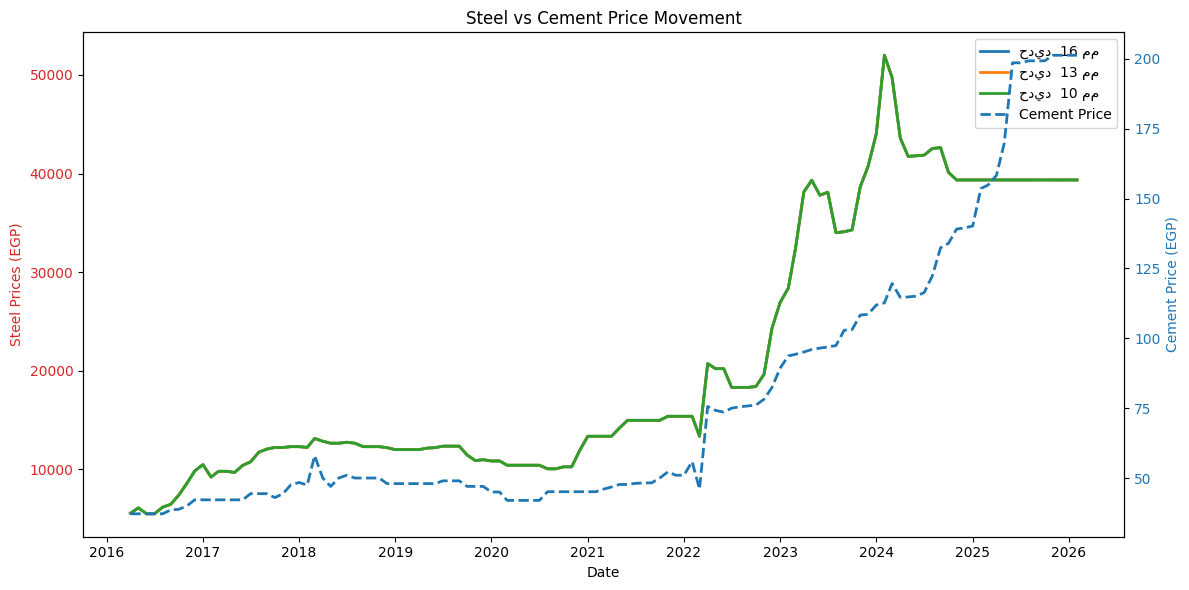

In [20]:
import matplotlib.pyplot as plt

print("Available columns in dataset:")
print(df_merged.columns.tolist())

df_merged["Date"] = pd.to_datetime(df_merged["Date"])

steel_cols = [col for col in df_merged.columns if 'حديد' in col]

cement_col = "cement_price" if "cement_price" in df_merged.columns else None

if not steel_cols:
    raise ValueError("No steel columns found")

fig, ax1 = plt.subplots(figsize=(12, 6))

for col in steel_cols:
    ax1.plot(df_merged['Date'], df_merged[col], label=col, linewidth=2)

ax1.set_xlabel("Date")
ax1.set_ylabel("Steel Prices (EGP)", color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

if cement_col:
    ax2 = ax1.twinx()
    ax2.plot(df_merged['Date'], df_merged[cement_col],
             label="Cement Price",
             linewidth=2,
             linestyle='--',
             color='tab:blue')
    ax2.set_ylabel("Cement Price (EGP)", color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

lines1, labels1 = ax1.get_legend_handles_labels()
if cement_col:
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("Steel vs Cement Price Movement")
plt.tight_layout()
plt.show()

In [21]:
# Ensure datetime
df_merged["Date"] = pd.to_datetime(df_merged["Date"])
df_usd_monthly["Date"] = pd.to_datetime(df_usd_monthly["Date"])

# Convert to monthly format only if needed
df_merged["Date"] = df_merged["Date"].dt.to_period("M").dt.to_timestamp()
df_usd_monthly["Date"] = df_usd_monthly["Date"].dt.to_period("M").dt.to_timestamp()

# Merge
df_final = pd.merge(
    df_merged,
    df_usd_monthly[["Date", "USD_Average"]],
    on="Date",
    how="left"
)

# Validation
print("Missing USD values:", df_final["USD_Average"].isnull().sum())
print("Total rows after merge:", len(df_final))

print("Final dataset preview:")
display(df_final.head(10))

Missing USD values: 0
Total rows after merge: 119
Final dataset preview:


,Date,cement_price,حديد 16 مم,حديد 13 مم,حديد 10 مم,USD_Average
0,2016-04-01,37.2,5555.0,5555.0,5555.0,8.856905
1,2016-05-01,37.2,6090.6,6090.6,6090.6,8.857295
2,2016-06-01,37.2,5490.8,5490.8,5490.8,8.841650
3,2016-07-01,37.2,5490.8,5490.8,5490.8,8.851590
4,2016-08-01,37.2,6159.5,6159.5,6159.5,8.865178
5,2016-09-01,38.6,6457.1,6457.1,6457.1,8.868155
6,2016-10-01,38.8,7377.0,7377.0,7377.0,8.868728
7,2016-11-01,40.0,8573.3,8573.3,8573.3,15.663632
8,2016-12-01,42.2,9836.7,9836.7,9836.7,18.454614
9,2017-01-01,42.2,10480.4,10480.4,10480.4,18.596886


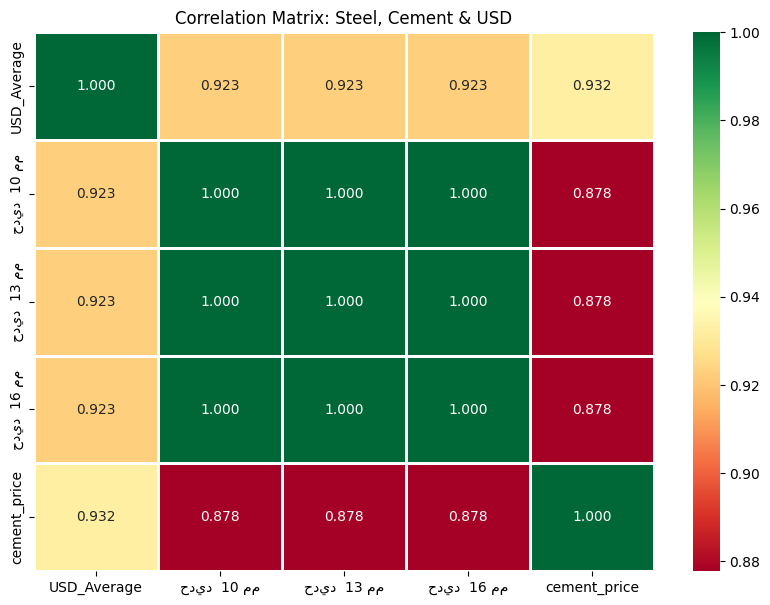

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_cols = [
    'USD_Average',
    'حديد  10 مم',
    'حديد  13 مم',
    'حديد  16 مم',
    'cement_price'
]

# Keep only existing columns (safety layer)
selected_cols = [col for col in selected_cols if col in df_final.columns]

corr_matrix = df_final[selected_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".3f", linewidths=1)

plt.title('Correlation Matrix: Steel, Cement & USD')
plt.show()

In [23]:
import yfinance as yf
import pandas as pd

def get_energy_data():
    print("جاري جلب بيانات الطاقة العالمية...")

    energy = yf.download(
        ["BZ=F", "NG=F"],
        start="2016-04-01",
        end="2026-05-01"
    )

    # استخراج Close فقط
    close = energy['Close'].copy()

    # التأكد من datetime index
    close.index = pd.to_datetime(close.index)

    # تحويل شهري
    energy_monthly = close.resample('MS').mean().reset_index()

    # rename columns بشكل آمن
    energy_monthly.columns = ['Date', 'Brent_Oil_USD', 'Natural_Gas_USD']

    return energy_monthly

df_energy_global = get_energy_data()

print("Table ready:")
display(df_energy_global.head(10))

جاري جلب بيانات الطاقة العالمية...


/tmp/ipykernel_5117/2977346931.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  energy = yf.download(
[*********************100%***********************]  2 of 2 completed

Table ready:


,Date,Brent_Oil_USD,Natural_Gas_USD
0,2016-04-01,43.386666,2.014381
1,2016-05-01,47.739048,2.083429
2,2016-06-01,49.926818,2.623818
3,2016-07-01,46.331000,2.761400
4,2016-08-01,47.172608,2.722348
5,2016-09-01,47.298095,2.902905
6,2016-10-01,51.210500,3.064250
7,2016-11-01,47.108501,2.885550
8,2016-12-01,54.717619,3.583714
9,2017-01-01,55.427000,3.291200


In [24]:
import yfinance as yf
import pandas as pd

def get_metals_data():
    print("جاري جلب بيانات الخامات العالمية...")

    metals = yf.download(
        ["TIO=F", "HOLN.SW"],
        start="2016-04-01",
        end="2026-05-01"
    )

    close = metals['Close'].copy()
    close.index = pd.to_datetime(close.index)

    metals_monthly = close.resample('MS').mean().reset_index()

    metals_monthly.columns = [
        'Date',
        'Global_Iron_Ore_USD',
        'Global_Cement_Index'
    ]

    return metals_monthly

df_metals_global = get_metals_data()

print("Table ready:")
display(df_metals_global.head(10))

جاري جلب بيانات الخامات العالمية...


/tmp/ipykernel_5117/2338244731.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  metals = yf.download(
[*********************100%***********************]  2 of 2 completed

Table ready:


,Date,Global_Iron_Ore_USD,Global_Cement_Index
0,2016-04-01,32.234326,56.434285
1,2016-05-01,30.557426,56.770476
2,2016-06-01,29.158344,50.292727
3,2016-07-01,30.102551,55.389500
4,2016-08-01,35.111837,60.257826
5,2016-09-01,35.973372,57.237143
6,2016-10-01,36.703565,56.285501
7,2016-11-01,37.591215,68.868500
8,2016-12-01,37.436271,78.990953
9,2017-01-01,37.139858,78.624001


In [25]:
import pandas as pd

# Ensure monthly alignment safely
for df in [df_final, df_energy_global, df_metals_global]:
    df['Date'] = pd.to_datetime(df['Date']).dt.to_period('M').dt.to_timestamp()

# Merge step-by-step
df_raw_combined = pd.merge(df_final, df_energy_global, on='Date', how='left')
df_raw_combined = pd.merge(df_raw_combined, df_metals_global, on='Date', how='left')

# Safe column selection (avoid crashes)
requested_cols = [
    'Date',
    'cement_price',
    'حديد  16 مم',
    'حديد  13 مم',
    'حديد  10 مم',
    'USD_Average',
    'Global_Cement_Index',
    'Global_Iron_Ore_USD',
    'Brent_Oil_USD',
    'Natural_Gas_USD'
]

existing_cols = [col for col in requested_cols if col in df_raw_combined.columns]

df_final_raw = df_raw_combined[existing_cols]

print("Final merged dataset:")
display(df_final_raw.tail(15))

Final merged dataset:


,Date,cement_price,حديد 16 مم,حديد 13 مم,حديد 10 مم,USD_Average,Global_Cement_Index,Global_Iron_Ore_USD,Brent_Oil_USD,Natural_Gas_USD
104,2024-12-01,139.5,39351.7,39351.7,39351.7,50.507359,104.919524,86.326721,73.128572,3.406619
105,2025-01-01,140.2,39352.8,39352.8,39352.8,50.433341,100.192380,85.726580,78.263334,3.721381
106,2025-02-01,153.6,39352.9,39352.9,39352.9,50.493034,106.583684,92.393393,74.940526,3.740947
107,2025-03-01,154.9,39353.0,39353.0,39353.0,50.562119,101.861905,95.951711,71.467142,4.137476
108,2025-04-01,158.3,39353.0,39353.0,39353.0,50.937596,100.570953,85.549259,66.456667,3.425762
109,2025-05-01,169.9,39353.0,39353.0,39353.0,50.246739,99.388572,93.402984,63.970476,3.460810
110,2025-06-01,198.6,39352.8,39352.8,39352.8,49.890973,95.200500,71.438612,69.350000,3.643650
111,2025-07-01,198.6,39352.7,39352.7,39352.7,49.267807,97.102273,62.885218,69.553044,3.306130
112,2025-08-01,199.3,39352.9,39352.9,39352.9,48.415065,101.467142,67.048999,67.261428,2.888524
113,2025-09-01,199.3,39354.0,39354.0,39354.0,48.173556,105.098095,67.613636,67.548571,3.009762


In [26]:
import pandas as pd
import numpy as np

final_cols = [
    'Date',
    'cement_price',
    'حديد  16 مم',
    'USD_Average',
    'Global_Cement_Index',
    'Global_Iron_Ore_USD',
    'Brent_Oil_USD',
    'Natural_Gas_USD'
]

# keep only existing columns (safety)
final_cols = [col for col in final_cols if col in df_final_raw.columns]

df_refined = df_final_raw[final_cols].copy()

df_refined = df_refined.sort_values("Date").reset_index(drop=True)

base = df_refined.dropna().iloc[0]

df_refined['Local_Index'] = (
    df_refined['حديد  16 مم'] / base['حديد  16 مم']
) * 100

df_refined['Global_Index'] = (
    (df_refined['Global_Iron_Ore_USD'] / base['Global_Iron_Ore_USD'] * 0.40) +
    (df_refined['Brent_Oil_USD'] / base['Brent_Oil_USD'] * 0.30) +
    (df_refined['Natural_Gas_USD'] / base['Natural_Gas_USD'] * 0.30)
) * 100

df_refined['Global_Index_aligned'] = df_refined['Global_Index']

df_refined['Total_Correlation_Factor'] = (
    df_refined['Local_Index']
    .rolling(window=6, min_periods=3)
    .corr(df_refined['Global_Index_aligned'])
)

df_refined['Total_Correlation_Factor'] = df_refined['Total_Correlation_Factor'].round(3)

print("Final dataset:")
display(df_refined.tail(15))

Final dataset:


,Date,cement_price,حديد 16 مم,USD_Average,Global_Cement_Index,Global_Iron_Ore_USD,Brent_Oil_USD,Natural_Gas_USD,Local_Index,Global_Index,Global_Index_aligned,Total_Correlation_Factor
104,2024-12-01,139.5,39351.7,50.507359,104.919524,86.326721,73.128572,3.406619,708.401440,208.423685,208.423685,-0.911
105,2025-01-01,140.2,39352.8,50.433341,100.192380,85.726580,78.263334,3.721381,708.421242,215.917149,215.917149,-0.888
106,2025-02-01,153.6,39352.9,50.493034,106.583684,92.393393,74.940526,3.740947,708.423042,222.183909,222.183909,-0.786
107,2025-03-01,154.9,39353.0,50.562119,101.861905,95.951711,71.467142,4.137476,708.424842,230.103248,230.103248,-0.718
108,2025-04-01,158.3,39353.0,50.937596,100.570953,85.549259,66.456667,3.425762,708.424842,203.130681,203.130681,0.551
109,2025-05-01,169.9,39353.0,50.246739,99.388572,93.402984,63.970476,3.460810,708.424842,211.679341,211.679341,0.321
110,2025-06-01,198.6,39352.8,49.890973,95.200500,71.438612,69.350000,3.643650,708.421242,190.866197,190.866197,0.377
111,2025-07-01,198.6,39352.7,49.267807,97.102273,62.885218,69.553044,3.306130,708.419442,175.365923,175.365923,0.807
112,2025-08-01,199.3,39352.9,48.415065,101.467142,67.048999,67.261428,2.888524,708.423042,172.728883,172.728883,0.739
113,2025-09-01,199.3,39354.0,48.173556,105.098095,67.613636,67.548571,3.009762,708.442844,175.433682,175.433682,-0.204


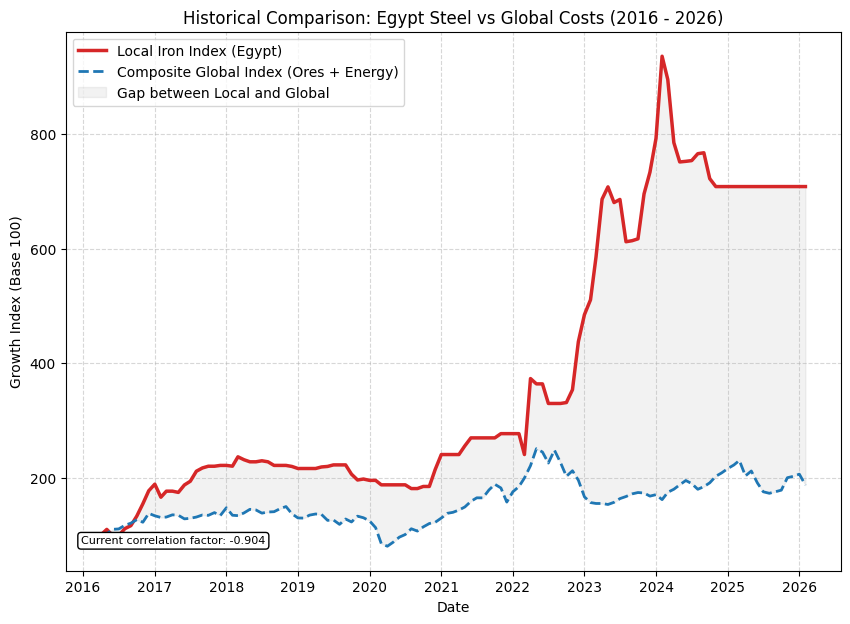

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Local index
plt.plot(
    df_refined['Date'],
    df_refined['Local_Index'],
    label='Local Iron Index (Egypt)',
    color='#d62728',
    linewidth=2.5
)

# Use precomputed global index (IMPORTANT)
global_index = df_refined['Global_Index']

plt.plot(
    df_refined['Date'],
    global_index,
    label='Composite Global Index (Ores + Energy)',
    color='#1f77b4',
    linestyle='--',
    linewidth=2
)

# Gap shading (single clean logic)
plt.fill_between(
    df_refined['Date'],
    df_refined['Local_Index'],
    global_index,
    alpha=0.1,
    color='gray',
    label='Gap between Local and Global'
)

plt.title('Historical Comparison: Egypt Steel vs Global Costs (2016 - 2026)')
plt.xlabel('Date')
plt.ylabel('Growth Index (Base 100)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

current_corr = df_refined['Total_Correlation_Factor'].iloc[-1]

plt.annotate(
    f'Current correlation factor: {current_corr}',
    xy=(0.02, 0.05),
    xycoords='axes fraction',
    fontsize=8,
    bbox=dict(boxstyle="round", fc="white")
)

plt.show()

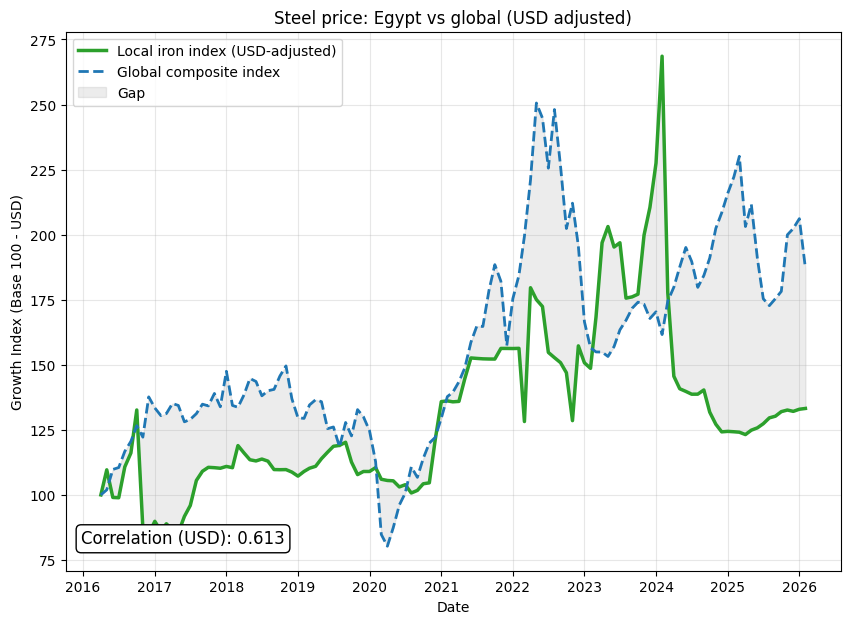

In [28]:
import matplotlib.pyplot as plt

# Ensure no missing USD
df_refined = df_refined.dropna(subset=['USD_Average'])

# USD-adjusted steel price
df_refined['Steel_USD_Price'] = (
    df_refined['حديد  16 مم'] / df_refined['USD_Average']
)

# Safe base (first valid row)
base_usd_price = df_refined['Steel_USD_Price'].dropna().iloc[0]

df_refined['Local_Index_USD'] = (
    df_refined['Steel_USD_Price'] / base_usd_price
) * 100

# Use precomputed global index if available
global_index = df_refined['Global_Index'] if 'Global_Index' in df_refined.columns else None

plt.figure(figsize=(10, 7))

plt.plot(
    df_refined['Date'],
    df_refined['Local_Index_USD'],
    label='Local iron index (USD-adjusted)',
    color='#2ca02c',
    linewidth=2.5
)

if global_index is not None:
    plt.plot(
        df_refined['Date'],
        global_index,
        label='Global composite index',
        color='#1f77b4',
        linestyle='--',
        linewidth=2
    )

    plt.fill_between(
        df_refined['Date'],
        df_refined['Local_Index_USD'],
        global_index,
        alpha=0.15,
        color='gray',
        label='Gap'
    )

plt.title('Steel price: Egypt vs global (USD adjusted)')
plt.xlabel('Date')
plt.ylabel('Growth Index (Base 100 - USD)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Safe rolling correlation
if global_index is not None:
    new_corr = (
        df_refined['Local_Index_USD']
        .rolling(window=6, min_periods=3)
        .corr(global_index)
        .iloc[-1]
    )

    plt.annotate(
        f'Correlation (USD): {new_corr:.3f}',
        xy=(0.02, 0.05),
        xycoords='axes fraction',
        fontsize=12,
        bbox=dict(boxstyle="round", fc="white")
    )

plt.show()

In [30]:
import pandas as pd
import numpy as np

local_series = df_refined['Local_Index_USD']
global_series = df_refined['Global_Index']

lag_results = {}

for lag in range(0, 7):
    shifted_global = global_series.shift(lag)
    correlation = local_series.corr(shifted_global)
    lag_results[lag] = correlation
# lag identification
best_lag = max(lag_results, key=lag_results.get)
max_corr = lag_results[best_lag]

print("Time-Lag Analysis Results:")
print("-" * 40)

for lag, corr in lag_results.items():
    star = " (best)" if lag == best_lag else ""
    print(f"Lag {lag} months: correlation coefficient = {corr:.3f}{star}")

print("-" * 40)
print(f"Best lag: {best_lag} months")

Time-Lag Analysis Results:
----------------------------------------
Lag 0 months: correlation coefficient = 0.502 (best)
Lag 1 months: correlation coefficient = 0.488
Lag 2 months: correlation coefficient = 0.470
Lag 3 months: correlation coefficient = 0.461
Lag 4 months: correlation coefficient = 0.453
Lag 5 months: correlation coefficient = 0.445
Lag 6 months: correlation coefficient = 0.448
----------------------------------------
Best lag: 0 months


In [31]:
import pandas as pd
import numpy as np

# Ensure clean alignment
df_lag = df_refined.copy().sort_values("Date").reset_index(drop=True)

local_series = df_lag['Local_Index_USD']

# Use official global index (NOT plot variable)
global_series = df_lag['Global_Index']

lag_results = {}

for lag in range(0, 7):

    # shift global backward to simulate leading effect
    shifted_global = global_series.shift(lag)

    # align properly
    corr = local_series.corr(shifted_global)

    lag_results[lag] = corr

best_lag = max(lag_results, key=lag_results.get)
max_corr = lag_results[best_lag]

print("Time-Lag Analysis Results:")
print("-" * 40)

for lag, corr in lag_results.items():
    star = " (best)" if lag == best_lag else ""
    print(f"Lag {lag} months: correlation = {corr:.3f}{star}")

print("-" * 40)

print(
    f"Conclusion: Optimal lag = {best_lag} months with correlation {max_corr:.3f}"
)

Time-Lag Analysis Results:
----------------------------------------
Lag 0 months: correlation = 0.502 (best)
Lag 1 months: correlation = 0.488
Lag 2 months: correlation = 0.470
Lag 3 months: correlation = 0.461
Lag 4 months: correlation = 0.453
Lag 5 months: correlation = 0.445
Lag 6 months: correlation = 0.448
----------------------------------------
Conclusion: Optimal lag = 0 months with correlation 0.502


In [32]:
import numpy as np
import pandas as pd

df_refined = df_refined.sort_values("Date").reset_index(drop=True)

df_refined['Global_Iron_Lagged'] = df_refined['Global_Iron_Ore_USD'].shift(1)
df_refined['Oil_Lagged'] = df_refined['Brent_Oil_USD'].shift(1)

df_refined['Local_Index_USD'] = (
    df_refined['حديد  16 مم'] / df_refined['USD_Average']
)

In [33]:
features = [
    'حديد  16 مم',
    'USD_Average',
    'Global_Iron_Lagged',
    'Oil_Lagged',
    'Local_Index_USD'
]

df_final_model = df_refined[features].dropna()
dataset = df_final_model.values

In [34]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

In [35]:
time_steps = 12

x_final = []
y_final = []

for i in range(time_steps, len(scaled_data)):
    x_final.append(scaled_data[i - time_steps:i])
    y_final.append(scaled_data[i, 0])

x_final = np.array(x_final)
y_final = np.array(y_final)

In [36]:
training_len = int(np.ceil(len(x_final) * 0.8))

x_train = x_final[:training_len]
y_train = y_final[:training_len]

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(x_final.shape[1], x_final.shape[2])),
    LSTM(32, return_sequences=False),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, batch_size=4, epochs=50, verbose=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0305
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0068
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0084
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0062
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0072
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0054
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0044
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0040
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0041
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0064
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0078
Epoch 12/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0056
Epoch 13/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0040
Epoch 14/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0060
Epoch 15/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0035
Epoch 16/50
22/

In [38]:
last_window = scaled_data[-time_steps:]
last_window_reshaped = np.reshape(
    last_window,
    (1, time_steps, len(features))
)

prediction_scaled = model.predict(last_window_reshaped)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step


In [43]:
prediction_scaled = model.predict(last_window_reshaped)

prediction_scaled_value = float(prediction_scaled[0][0])

dummy_scaler = np.zeros((1, len(features)))
dummy_scaler[0, 0] = prediction_scaled_value

prediction_final = scaler.inverse_transform(dummy_scaler)[0, 0]

print("Final forecast for June 2026:")
print(f"{prediction_final:,.2f} EGP")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
Final forecast for June 2026:
45,276.88 EGP


In [44]:
train_size = int(len(x_final) * 0.8)

x_train = x_final[:train_size]
x_test = x_final[train_size:]

y_train = y_final[:train_size]
y_test = y_final[train_size:]

In [45]:
y_pred = model.predict(x_test)
y_pred = y_pred.reshape(-1, 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step


In [46]:
y_test_arr = np.array(y_test).reshape(-1, 1)
y_pred_arr = y_pred.reshape(-1, 1)

dummy_test = np.zeros((len(y_test_arr), len(features)))
dummy_pred = np.zeros((len(y_pred_arr), len(features)))

dummy_test[:, 0] = y_test_arr[:, 0]
dummy_pred[:, 0] = y_pred_arr[:, 0]

y_test_inv = scaler.inverse_transform(dummy_test)[:, 0]
y_pred_inv = scaler.inverse_transform(dummy_pred)[:, 0]

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

print("MODEL PERFORMANCE")
print("-" * 30)
print(f"MAE  = {mae:,.2f}")
print(f"RMSE = {rmse:,.2f}")
print(f"MAPE = {mape:.2f}%")

MODEL PERFORMANCE
------------------------------
MAE  = 10,405.35
RMSE = 11,883.53
MAPE = 25.97%


In [48]:
import numpy as np
import pandas as pd

In [49]:
ml_data = df_final_model.copy()

X_ml = ml_data.drop(columns=['حديد  16 مم'])
y_ml = ml_data['حديد  16 مم']

In [50]:
train_size = int(len(X_ml) * 0.8)

X_train_ml = X_ml[:train_size]
X_test_ml = X_ml[train_size:]

y_train_ml = y_ml[:train_size]
y_test_ml = y_ml[train_size:]

In [51]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_ml, y_train_ml)
lr_pred = lr_model.predict(X_test_ml)

In [52]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_ml, y_train_ml)
ridge_pred = ridge_model.predict(X_test_ml)

In [53]:
lstm_pred = model.predict(x_test)

# inverse scaling
dummy_lstm = np.zeros((len(lstm_pred), len(features)))
dummy_lstm[:, 0] = lstm_pred[:, 0]

lstm_pred_inv = scaler.inverse_transform(dummy_lstm)[:, 0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


In [54]:
min_len = min(len(lr_pred), len(ridge_pred), len(lstm_pred_inv))

lr_pred = lr_pred[-min_len:]
ridge_pred = ridge_pred[-min_len:]
lstm_pred = lstm_pred_inv[-min_len:]
y_true = y_test_ml[-min_len:]

In [55]:
ensemble_pred = (
    0.4 * lstm_pred +
    0.3 * ridge_pred +
    0.3 * lr_pred
)

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true, ensemble_pred)
rmse = np.sqrt(mean_squared_error(y_true, ensemble_pred))
mape = np.mean(np.abs((y_true - ensemble_pred) / y_true)) * 100

print("ENSEMBLE MODEL PERFORMANCE")
print("-" * 30)
print(f"MAE  = {mae:,.2f}")
print(f"RMSE = {rmse:,.2f}")
print(f"MAPE = {mape:.2f}%")

ENSEMBLE MODEL PERFORMANCE
------------------------------
MAE  = 7,488.76
RMSE = 7,900.50
MAPE = 18.75%


In [57]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

target = df_refined['حديد  16 مم']

X = df_refined.drop(columns=['Date', 'حديد  16 مم'])
X = X.fillna(method='ffill')

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X, target)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

/tmp/ipykernel_5117/72764417.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='ffill')


,0
Local_Index,0.362551
USD_Average,0.342265
cement_price,0.133383
Global_Iron_Ore_USD,0.107470
Global_Iron_Lagged,0.034743
Steel_USD_Price,0.004093
Local_Index_USD,0.003680
Natural_Gas_USD,0.003349
Global_Index,0.002540
Global_Index_aligned,0.002154


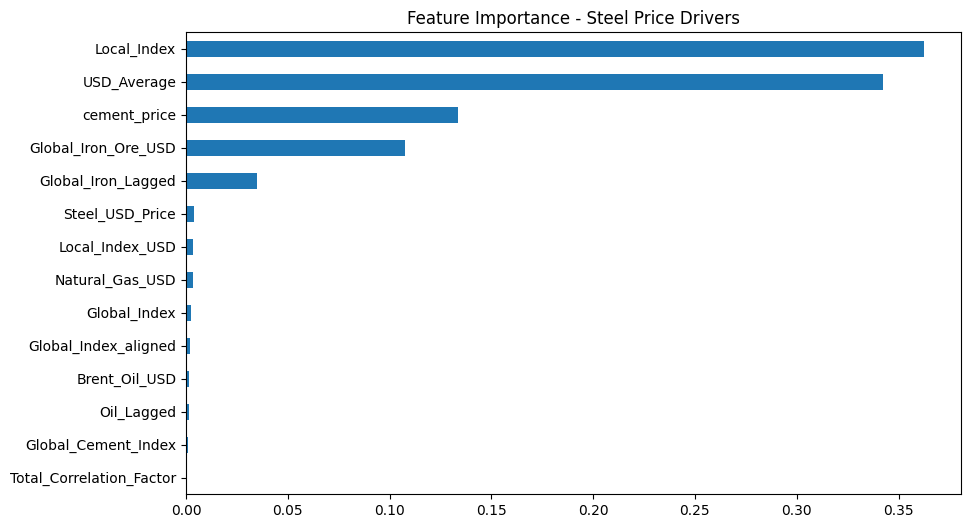

In [58]:
import matplotlib.pyplot as plt

importance.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance - Steel Price Drivers")
plt.show()

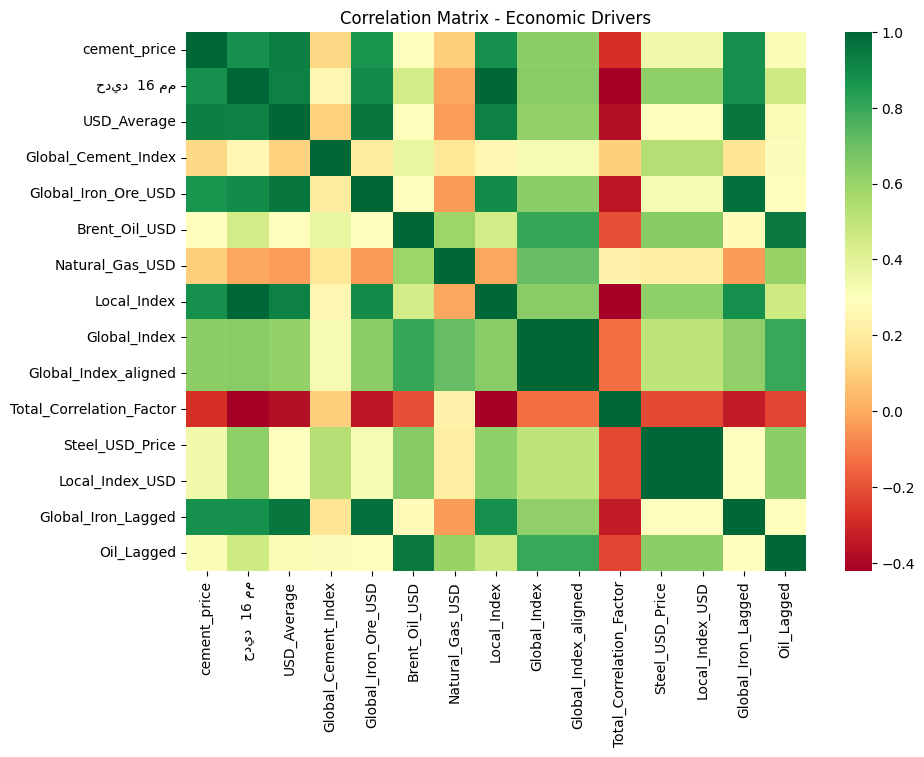

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_refined.drop(columns=['Date']).corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, cmap='RdYlGn', annot=False)
plt.title("Correlation Matrix - Economic Drivers")
plt.show()

In [60]:
lags = range(0, 6)
results = {}

for lag in lags:
    shifted = df_refined['Global_Iron_Ore_USD'].shift(lag)
    results[lag] = df_refined['حديد  16 مم'].corr(shifted)

print("Lag Analysis:")
for k,v in results.items():
    print(f"Lag {k}: {v:.3f}")

Lag Analysis:
Lag 0: 0.891
Lag 1: 0.876
Lag 2: 0.861
Lag 3: 0.844
Lag 4: 0.825
Lag 5: 0.806


In [62]:
import pandas as pd

raw = pd.read_excel(
    "Monthly Interest Rates Historical.xlsx",
    sheet_name="Monthly Rates",
    skiprows=3,
    header=None
)

print(raw.head())

             0      1      2      3      4
0    مارس 2026  14.8%  14.0%  14.2%  20.6%
1  فبراير 2026  14.7%  14.0%  14.3%  20.7%
2   يناير 2026  15.3%  14.4%  14.6%  21.3%
3  ديسمبر 2025  15.9%  14.9%  14.9%  21.5%
4  نوفمبر 2025  15.8%  15.3%  15.2%  21.7%


In [63]:
# العمود 0 = التاريخ
# العمود 4 = فائدة القروض (آخر عمود)

df_interest = raw[[0, 4]].copy()
df_interest.columns = ["Date_ar", "Interest_Rate"]

print(df_interest.head())

       Date_ar Interest_Rate
0    مارس 2026         20.6%
1  فبراير 2026         20.7%
2   يناير 2026         21.3%
3  ديسمبر 2025         21.5%
4  نوفمبر 2025         21.7%


In [64]:
arabic_months = {
    "يناير": "January",
    "فبراير": "February",
    "مارس": "March",
    "أبريل": "April",
    "مايو": "May",
    "يونيو": "June",
    "يوليو": "July",
    "أغسطس": "August",
    "سبتمبر": "September",
    "أكتوبر": "October",
    "نوفمبر": "November",
    "ديسمبر": "December"
}

def convert_date(text):
    if pd.isna(text):
        return None
    for ar, en in arabic_months.items():
        text = str(text).replace(ar, en)
    return text

df_interest["Date"] = df_interest["Date_ar"].apply(convert_date)
df_interest["Date"] = pd.to_datetime(df_interest["Date"], errors="coerce")

df_interest = df_interest.dropna(subset=["Date"])

/tmp/ipykernel_5117/2810854559.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_interest["Date"] = pd.to_datetime(df_interest["Date"], errors="coerce")


In [65]:
df_interest["Interest_Rate"] = (
    df_interest["Interest_Rate"]
    .astype(str)
    .str.replace("%", "", regex=True)
    .astype(float)
)

In [66]:
df_interest = (
    df_interest
    .sort_values("Date")
    .drop_duplicates(subset="Date")
)

df_interest = df_interest.set_index("Date")
df_interest = df_interest.resample("MS").ffill()

df_interest = df_interest.reset_index()

print(df_interest.head())

        Date     Date_ar  Interest_Rate
0 2016-04-01  أبريل 2016           12.9
1 2016-05-01   مايو 2016           12.9
2 2016-06-01  يونيو 2016           13.4
3 2016-07-01  يوليو 2016           13.8
4 2016-08-01  أغسطس 2016           13.8


In [67]:
df_interest = df_interest.drop(columns=["Date_ar"])

In [68]:
print(df_interest.head())
print(df_interest.info())

        Date  Interest_Rate
0 2016-04-01           12.9
1 2016-05-01           12.9
2 2016-06-01           13.4
3 2016-07-01           13.8
4 2016-08-01           13.8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           120 non-null    datetime64[ns]
 1   Interest_Rate  120 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.0 KB
None


In [70]:
import pandas as pd

raw_inf = pd.read_excel(
    "Inflations Historical.xlsx",
    sheet_name="Inflation Rates",
    skiprows=3,
    header=None
)

print(raw_inf.head(10))

             0        1        2        3        4
0  فبراير 2026  13.400%  12.700%  15.100%  16.900%
1   يناير 2026  11.900%  11.200%  15.400%   7.500%
2  ديسمبر 2025  12.300%  11.800%  16.200%   4.400%
3  نوفمبر 2025  12.300%  12.500%  16.500%  -3.600%
4  أكتوبر 2025  12.500%  12.100%  18.100%   0.900%
5  سبتمبر 2025  11.700%  11.300%  19.400%  -5.200%
6   أغسطس 2025  12.000%  10.700%  22.400%  -4.500%
7   يوليو 2025  13.900%  11.600%  25.800%   2.400%
8   يونيو 2025  14.900%  11.400%  23.500%  30.600%
9    مايو 2025  16.800%  13.100%  26.700%  32.100%


In [71]:
df_inflation = raw_inf[[0, 1]].copy()
df_inflation.columns = ["Date_ar", "Inflation_Rate"]

print(df_inflation.head())

       Date_ar Inflation_Rate
0  فبراير 2026        13.400%
1   يناير 2026        11.900%
2  ديسمبر 2025        12.300%
3  نوفمبر 2025        12.300%
4  أكتوبر 2025        12.500%


In [72]:
arabic_months = {
    "يناير": "January",
    "فبراير": "February",
    "مارس": "March",
    "أبريل": "April",
    "مايو": "May",
    "يونيو": "June",
    "يوليو": "July",
    "أغسطس": "August",
    "سبتمبر": "September",
    "أكتوبر": "October",
    "نوفمبر": "November",
    "ديسمبر": "December"
}

def convert_date(text):
    if pd.isna(text):
        return None
    text = str(text)
    for ar, en in arabic_months.items():
        text = text.replace(ar, en)
    return text

df_inflation["Date"] = df_inflation["Date_ar"].apply(convert_date)
df_inflation["Date"] = pd.to_datetime(df_inflation["Date"], errors="coerce")

df_inflation = df_inflation.dropna(subset=["Date"])

/tmp/ipykernel_5117/372423720.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_inflation["Date"] = pd.to_datetime(df_inflation["Date"], errors="coerce")


In [73]:
df_inflation["Inflation_Rate"] = (
    df_inflation["Inflation_Rate"]
    .astype(str)
    .str.replace("%", "", regex=True)
    .astype(float)
)

In [74]:
df_inflation = (
    df_inflation
    .sort_values("Date")
    .drop_duplicates(subset="Date")
)

df_inflation = df_inflation.set_index("Date")
df_inflation = df_inflation.resample("MS").ffill()

df_inflation = df_inflation.reset_index()

# حذف العمود العربي
df_inflation = df_inflation.drop(columns=["Date_ar"])

print(df_inflation.head())
print(df_inflation.info())

        Date  Inflation_Rate
0 2016-04-01          10.274
1 2016-05-01          12.300
2 2016-06-01          13.969
3 2016-07-01          13.999
4 2016-08-01          15.469
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            119 non-null    datetime64[ns]
 1   Inflation_Rate  119 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.0 KB
None


In [75]:
df_macro = pd.merge(
    df_interest,
    df_inflation,
    on="Date",
    how="outer"
)

df_macro = df_macro.sort_values("Date").ffill()

print(df_macro.head())

        Date  Interest_Rate  Inflation_Rate
0 2016-04-01           12.9          10.274
1 2016-05-01           12.9          12.300
2 2016-06-01           13.4          13.969
3 2016-07-01           13.8          13.999
4 2016-08-01           13.8          15.469


In [76]:
df_refined = pd.merge(
    df_refined,
    df_macro,
    on="Date",
    how="left"
)

print(df_refined.head())
print(df_refined.isnull().sum())

        Date  cement_price  حديد  16 مم  USD_Average  Global_Cement_Index  \
0 2016-04-01          37.2       5555.0     8.856905            56.434285   
1 2016-05-01          37.2       6090.6     8.857295            56.770476   
2 2016-06-01          37.2       5490.8     8.841650            50.292727   
3 2016-07-01          37.2       5490.8     8.851590            55.389500   
4 2016-08-01          37.2       6159.5     8.865178            60.257826   

   Global_Iron_Ore_USD  Brent_Oil_USD  Natural_Gas_USD  Local_Index  \
0            32.234326      43.386666         2.014381   100.000000   
1            30.557426      47.739048         2.083429   109.641764   
2            29.158344      49.926818         2.623818    98.844284   
3            30.102551      46.331000         2.761400    98.844284   
4            35.111837      47.172608         2.722348   110.882088   

   Global_Index  Global_Index_aligned  Total_Correlation_Factor  \
0    100.000000            100.000000      

In [77]:
print(" Preview of final merged dataset:")
display(df_refined.head(10))

 Preview of final merged dataset:


,Date,cement_price,حديد 16 مم,USD_Average,Global_Cement_Index,Global_Iron_Ore_USD,Brent_Oil_USD,Natural_Gas_USD,Local_Index,Global_Index,Global_Index_aligned,Total_Correlation_Factor,Steel_USD_Price,Local_Index_USD,Global_Iron_Lagged,Oil_Lagged,Interest_Rate,Inflation_Rate
0,2016-04-01,37.2,5555.0,8.856905,56.434285,32.234326,43.386666,2.014381,100.000000,100.000000,100.000000,NaN,627.194286,627.194286,NaN,NaN,12.9,10.274
1,2016-05-01,37.2,6090.6,8.857295,56.770476,30.557426,47.739048,2.083429,109.641764,101.956916,101.956916,NaN,687.636542,687.636542,32.234326,43.386666,12.9,12.300
2,2016-06-01,37.2,5490.8,8.841650,50.292727,29.158344,49.926818,2.623818,98.844284,109.781500,109.781500,-0.418,621.015311,621.015311,30.557426,47.739048,13.4,13.969
3,2016-07-01,37.2,5490.8,8.851590,55.389500,30.102551,46.331000,2.761400,98.844284,110.515820,110.515820,-0.539,620.317905,620.317905,29.158344,49.926818,13.8,13.999
4,2016-08-01,37.2,6159.5,8.865178,60.257826,35.111837,47.172608,2.722348,110.882088,116.732245,116.732245,0.214,694.797089,694.797089,30.102551,46.331000,13.8,15.469
5,2016-09-01,38.6,6457.1,8.868155,57.237143,35.973372,47.298095,2.902905,116.239424,120.577122,120.577122,0.565,728.122179,728.122179,35.111837,47.172608,13.9,14.088
6,2016-10-01,38.8,7377.0,8.868728,56.285501,36.703565,51.210500,3.064250,132.799280,126.591387,126.591387,0.755,831.799061,831.799061,35.973372,47.298095,13.9,13.563
7,2016-11-01,40.0,8573.3,15.663632,68.868500,37.591215,47.108501,2.885550,154.334833,122.195166,122.195166,0.814,547.337941,547.337941,36.703565,51.210500,16.0,19.427
8,2016-12-01,42.2,9836.7,18.454614,78.990953,37.436271,54.717619,3.583714,177.078308,137.661968,137.661968,0.904,533.021179,533.021179,37.591215,47.108501,16.3,23.269
9,2017-01-01,42.2,10480.4,18.596886,78.624001,37.139858,55.427000,3.291200,188.666067,133.428263,133.428263,0.876,563.556702,563.556702,37.436271,54.717619,16.5,28.138


In [78]:
print("Columns:")
print(df_refined.columns.tolist())

print("\nData Info:")
df_refined.info()

print("\nMissing values:")
print(df_refined.isnull().sum())

Columns:
['Date', 'cement_price', 'حديد  16 مم', 'USD_Average', 'Global_Cement_Index', 'Global_Iron_Ore_USD', 'Brent_Oil_USD', 'Natural_Gas_USD', 'Local_Index', 'Global_Index', 'Global_Index_aligned', 'Total_Correlation_Factor', 'Steel_USD_Price', 'Local_Index_USD', 'Global_Iron_Lagged', 'Oil_Lagged', 'Interest_Rate', 'Inflation_Rate']

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      119 non-null    datetime64[ns]
 1   cement_price              119 non-null    float64       
 2   حديد  16 مم               119 non-null    float64       
 3   USD_Average               119 non-null    float64       
 4   Global_Cement_Index       119 non-null    float64       
 5   Global_Iron_Ore_USD       119 non-null    float64       
 6   Brent_Oil_USD             119 non-null    fl

In [79]:

cols_to_drop = [
    "Inflation",
    "Interest_Rate_x"
]

df_refined = df_refined.drop(columns=[c for c in cols_to_drop if c in df_refined.columns])

# 2.إعادة تسمية الأعمدة
df_refined = df_refined.rename(columns={
    "Inflation_Rate": "Inflation",
    "Interest_Rate_y": "Interest_Rate"
})

# 3. معالجة القيم الناقصة
df_refined = df_refined.sort_values("Date")

df_refined["Inflation"] = df_refined["Inflation"].ffill()
df_refined["Interest_Rate"] = df_refined["Interest_Rate"].ffill()

# Lag NaN
df_refined = df_refined.dropna()

print(" Final cleaned dataset:")
display(df_refined.head())
print(df_refined.isnull().sum())

 Final cleaned dataset:


,Date,cement_price,حديد 16 مم,USD_Average,Global_Cement_Index,Global_Iron_Ore_USD,Brent_Oil_USD,Natural_Gas_USD,Local_Index,Global_Index,Global_Index_aligned,Total_Correlation_Factor,Steel_USD_Price,Local_Index_USD,Global_Iron_Lagged,Oil_Lagged,Interest_Rate,Inflation
2,2016-06-01,37.2,5490.8,8.841650,50.292727,29.158344,49.926818,2.623818,98.844284,109.781500,109.781500,-0.418,621.015311,621.015311,30.557426,47.739048,13.4,13.969
3,2016-07-01,37.2,5490.8,8.851590,55.389500,30.102551,46.331000,2.761400,98.844284,110.515820,110.515820,-0.539,620.317905,620.317905,29.158344,49.926818,13.8,13.999
4,2016-08-01,37.2,6159.5,8.865178,60.257826,35.111837,47.172608,2.722348,110.882088,116.732245,116.732245,0.214,694.797089,694.797089,30.102551,46.331000,13.8,15.469
5,2016-09-01,38.6,6457.1,8.868155,57.237143,35.973372,47.298095,2.902905,116.239424,120.577122,120.577122,0.565,728.122179,728.122179,35.111837,47.172608,13.9,14.088
6,2016-10-01,38.8,7377.0,8.868728,56.285501,36.703565,51.210500,3.064250,132.799280,126.591387,126.591387,0.755,831.799061,831.799061,35.973372,47.298095,13.9,13.563


Date                        0
cement_price                0
حديد  16 مم                 0
USD_Average                 0
Global_Cement_Index         0
Global_Iron_Ore_USD         0
Brent_Oil_USD               0
Natural_Gas_USD             0
Local_Index                 0
Global_Index                0
Global_Index_aligned        0
Total_Correlation_Factor    0
Steel_USD_Price             0
Local_Index_USD             0
Global_Iron_Lagged          0
Oil_Lagged                  0
Interest_Rate               0
Inflation                   0
dtype: int64


In [80]:
from sklearn.model_selection import train_test_split

# Target (سعر الحديد)
target_col = "حديد  16 مم"

# Features (كل المؤثرات)
feature_cols = [
    'USD_Average',
    'Global_Iron_Ore_USD',
    'Brent_Oil_USD',
    'Natural_Gas_USD',
    'Inflation',
    'Interest_Rate',
    'Global_Iron_Lagged',
    'Oil_Lagged',
    'Local_Index_USD'
]

X = df_refined[feature_cols]
y = df_refined[target_col]

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [81]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# XGBoost
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5)
xgb.fit(X_train, y_train)

print(" Models trained successfully")

 Models trained successfully


In [82]:
import numpy as np

# Predictions
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

# Ensemble (weighted average)
ensemble_pred = (0.5 * rf_pred) + (0.5 * xgb_pred)

In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, ensemble_pred)
rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))
mape = np.mean(np.abs((y_test - ensemble_pred) / y_test)) * 100

print("ENSEMBLE V3 PERFORMANCE")
print("-" * 30)
print(f"MAE  = {mae:,.2f}")
print(f"RMSE = {rmse:,.2f}")
print(f"MAPE = {mape:.2f}%")

ENSEMBLE V3 PERFORMANCE
------------------------------
MAE  = 2,048.75
RMSE = 2,422.46
MAPE = 5.01%


In [85]:
df_refined = df_refined.dropna()

In [107]:
import joblib
from google.colab import files


joblib.dump(rf, 'rf_steel_model.pkl')
joblib.dump(xgb, 'xgb_steel_model.pkl')


joblib.dump(scaler, 'scaler.pkl')


df_refined.to_csv('refined_construction_data.csv', index=False)

print(" All files saved locally in Colab.")


files_to_download = [
    'rf_steel_model.pkl',
    'xgb_steel_model.pkl',
    'scaler.pkl',
    'refined_construction_data.csv'
]

for file in files_to_download:
    files.download(file)



 All files saved locally in Colab.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [106]:

print("--- All Available Columns in df_refined ---")
print(df_refined.columns.tolist())

print("\n--- First 2 rows of the entire dataset ---")
display(df_refined.head(2))


model_features = [
    'USD_Average', 'Global_Iron_Ore_USD', 'Brent_Oil_USD',
    'Natural_Gas_USD', 'Inflation', 'Interest_Rate',
    'Global_Iron_Lagged', 'Oil_Lagged', 'Local_Index_USD'
]

unused_cols = [c for c in df_refined.columns if c not in model_features and c != 'حديد  16 مم']
print(f"\n--- Columns NOT used in the model: ---\n{unused_cols}")

--- All Available Columns in df_refined ---
['Date', 'cement_price', 'حديد  16 مم', 'USD_Average', 'Global_Cement_Index', 'Global_Iron_Ore_USD', 'Brent_Oil_USD', 'Natural_Gas_USD', 'Local_Index', 'Global_Index', 'Global_Index_aligned', 'Total_Correlation_Factor', 'Steel_USD_Price', 'Local_Index_USD', 'Global_Iron_Lagged', 'Oil_Lagged', 'Interest_Rate', 'Inflation', 'Steel_Momentum', 'USD_Momentum']

--- First 2 rows of the entire dataset ---


,Date,cement_price,حديد 16 مم,USD_Average,Global_Cement_Index,Global_Iron_Ore_USD,Brent_Oil_USD,Natural_Gas_USD,Local_Index,Global_Index,Global_Index_aligned,Total_Correlation_Factor,Steel_USD_Price,Local_Index_USD,Global_Iron_Lagged,Oil_Lagged,Interest_Rate,Inflation,Steel_Momentum,USD_Momentum
5,2016-09-01,38.6,6457.1,8.868155,57.237143,35.973372,47.298095,2.902905,116.239424,120.577122,120.577122,0.565,728.122179,728.122179,35.111837,47.172608,13.9,14.088,0.175985,0.002998
6,2016-10-01,38.8,7377.0,8.868728,56.285501,36.703565,51.210500,3.064250,132.799280,126.591387,126.591387,0.755,831.799061,831.799061,35.973372,47.298095,13.9,13.563,0.343520,0.001936



--- Columns NOT used in the model: ---
['Date', 'cement_price', 'Global_Cement_Index', 'Local_Index', 'Global_Index', 'Global_Index_aligned', 'Total_Correlation_Factor', 'Steel_USD_Price', 'Steel_Momentum', 'USD_Momentum']
